In [1]:
import pickle
from pathlib import Path
from typing import Optional


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import powerlaw

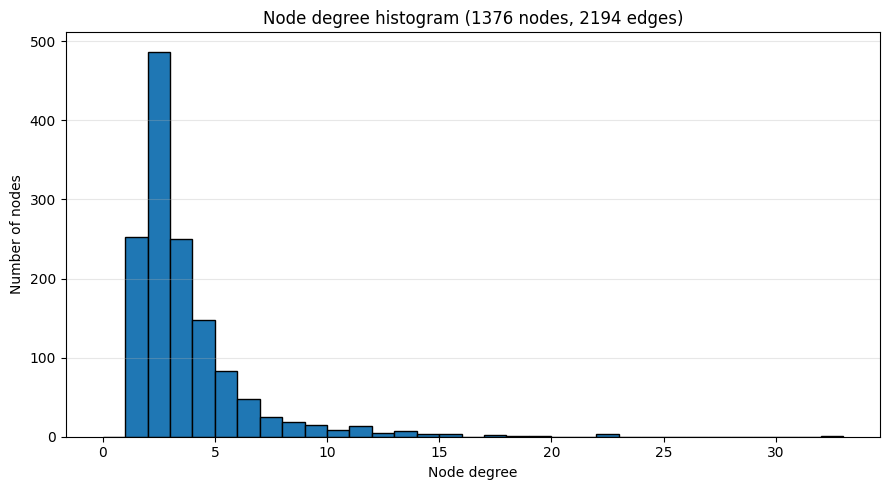

,degree
count,1376.000000
mean,3.188953
std,2.680417
min,1.000000
25%,2.000000
50%,2.000000
75%,4.000000
max,32.000000


In [2]:
GRAPH_PATH = Path("res/outage_graph.pkl")

with GRAPH_PATH.open("rb") as f:
    graph = pickle.load(f)

degrees = graph.degree()
degree_df = pd.DataFrame({"degree": degrees})

ax = degree_df["degree"].plot(
    kind="hist",
    bins=range(0, max(degrees) + 2),
    figsize=(9, 5),
    edgecolor="black",
)
ax.set_xlabel("Node degree")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Node degree histogram ({graph.vcount()} nodes, {graph.ecount()} edges)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

degree_df.describe()

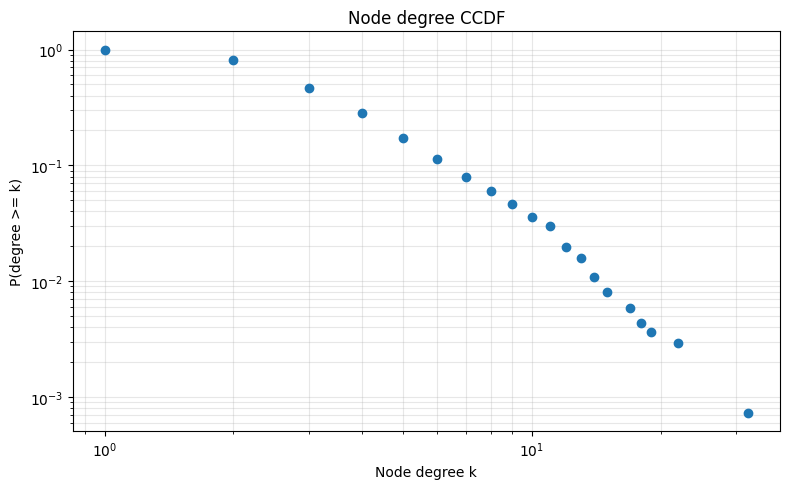

,degree,ccdf
0,1,1.000000
1,2,0.816860
2,3,0.462936
3,4,0.281250
4,5,0.173692
5,6,0.113372
6,7,0.078488
7,8,0.060320
8,9,0.046512
9,10,0.035610


In [3]:
if "degree_df" not in globals():
    GRAPH_PATH = Path("res/outage_graph.pkl")
    with GRAPH_PATH.open("rb") as f:
        graph = pickle.load(f)
    degree_df = pd.DataFrame({"degree": graph.degree()})

degree_counts = degree_df["degree"].value_counts().sort_index()
ccdf = degree_counts[::-1].cumsum()[::-1] / degree_counts.sum()

ax = ccdf.plot(
    marker="o",
    linestyle="none",
    figsize=(8, 5),
)
ax.set_xlabel("Node degree k")
ax.set_ylabel("P(degree >= k)")
ax.set_title("Node degree CCDF")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

ccdf.rename("ccdf").reset_index().rename(columns={"index": "degree"})

In [4]:
def plot_log_log(
    size_list: list[int],
    xmin: Optional[int] = None,
    xmax: Optional[int] = None,
    dpi: Optional[int] = 300,
    x_label: Optional[str] = "",
    y_label: Optional[str] = "",
):
    """Plot CCDF and fit a powerlaw distribution line to the points

    :param size_list: list of initial failure size, cascading failure size, cascading generations, etc.
    """
    fig, ax = plt.subplots(dpi=dpi)

    # plot log-log CCDF
    n = len(size_list)
    values, counts = np.unique(size_list, return_counts=True)
    order = np.argsort(values)
    values = values[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / n
    ax.loglog(values, ccdf, marker="o", linestyle="none")
    # ax.set_xlim(1, 50)

    # fit a line
    fit = powerlaw.Fit(
        size_list,
        discrete=True,
        verbose=False,
        survival=True,
        xmin=xmin,
        xmax=xmax,
    )
    print("alpha:", fit.power_law.alpha)
    print("xmin :", fit.power_law.xmin)
    fit.power_law.plot_pdf(ax=ax, linestyle="--", label="Power-law fit")

    # set labels
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    return ax

alpha: 3.0767765119077195
xmin : 4.0


PosixPath('output/node_degree_ccdf_powerlaw_fit.pdf')

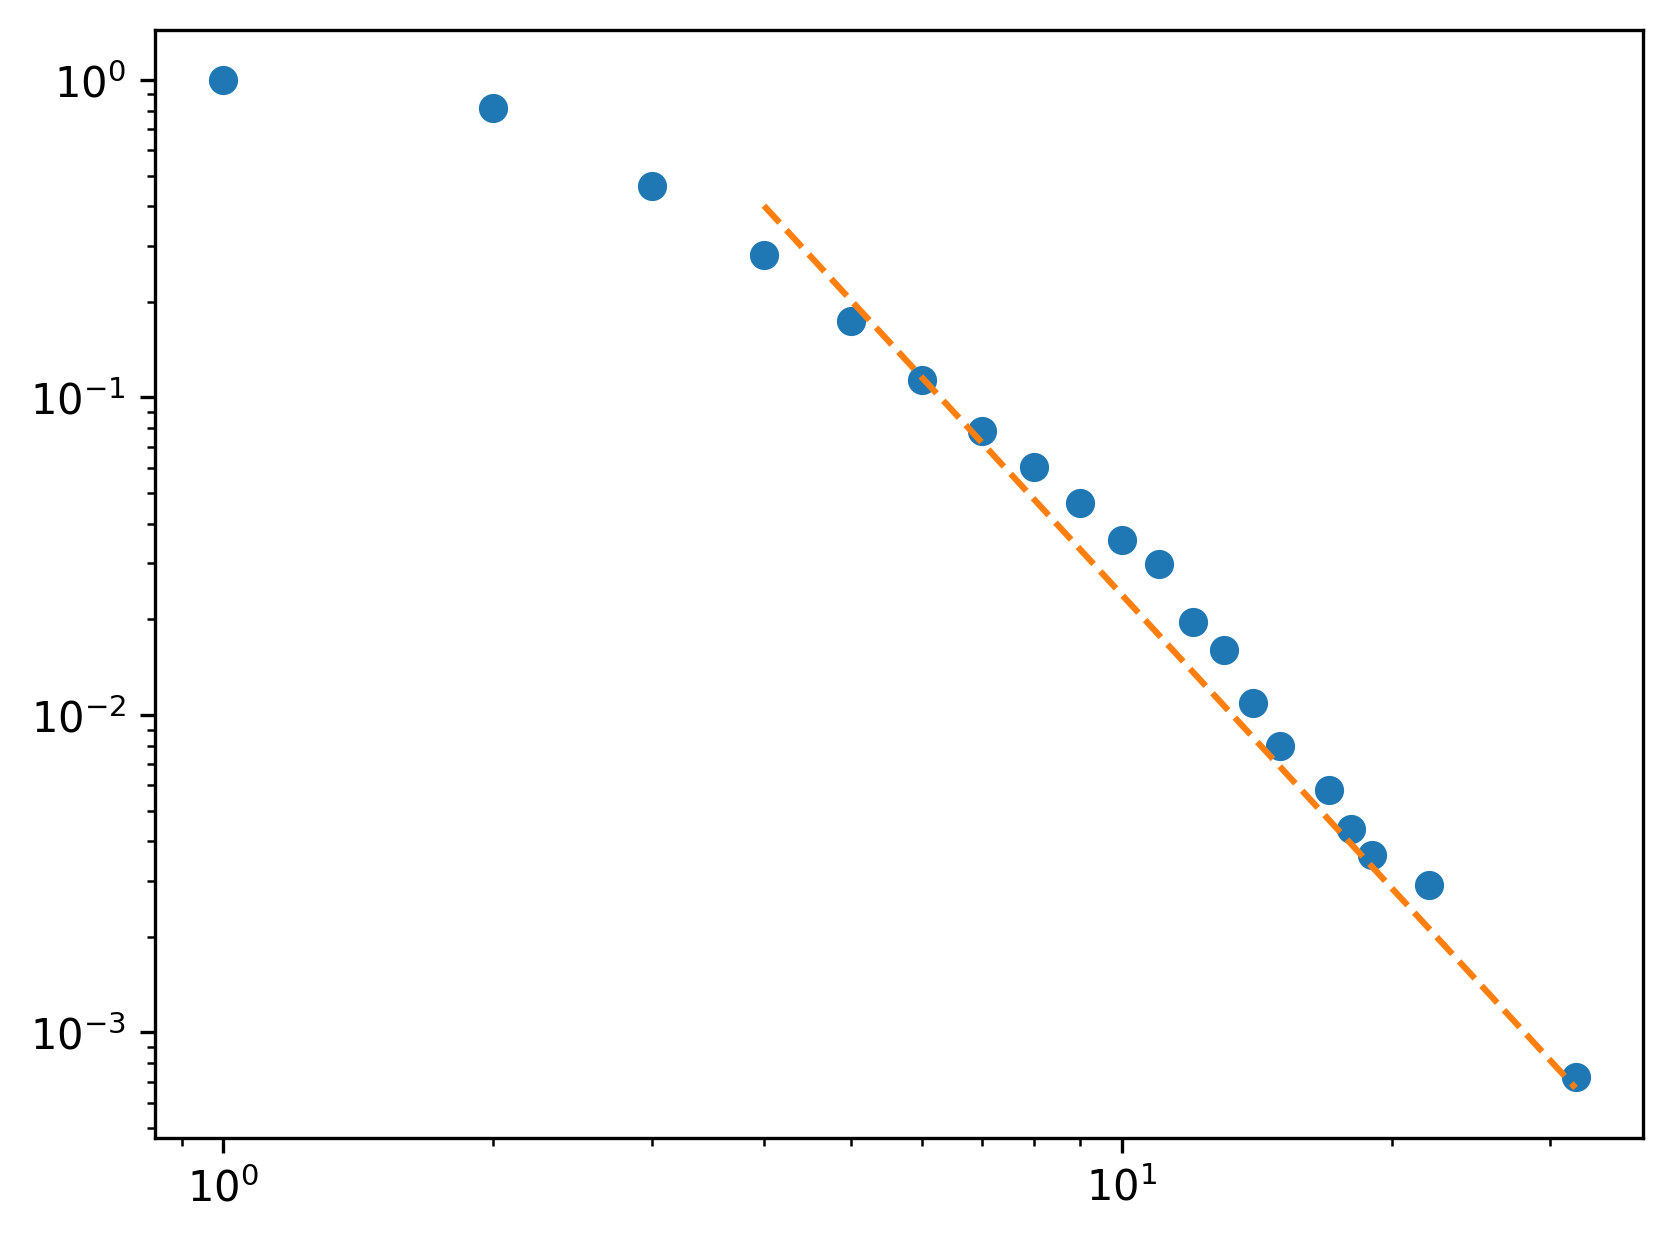

In [5]:
ax = plot_log_log(degrees)
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
plot_path = output_dir / "node_degree_ccdf_powerlaw_fit.pdf"

ax.figure.savefig(plot_path, dpi=300, bbox_inches="tight")
plot_path